In [ ]:
import json
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Visualization config
shap.initjs()
plt.rcParams["figure.figsize"] = (12, 4)

# Loading the final optimized model and the biological scaler from the research phase
model = joblib.load('models/anovator_age_gap_model.joblib')
scaler = joblib.load('models/anovator_biological_scaler.joblib')

# Loading the exact feature sequence required for model alignment
with open('models/model_features.json', 'r') as f:
    required_features = json.load(f)

# Loading training-set medians for safe missing-value imputation at inference time.
# These represent the "average patient" from training data — far safer than filling with 0
# (e.g. 0 vital capacity or 0 blood pressure would produce nonsensical predictions).
try:
    with open('models/training_medians.json', 'r') as f:
        training_medians = json.load(f)
    print(f"Training medians loaded: {len(training_medians)} feature medians available.")
except FileNotFoundError:
    training_medians = {}
    print("WARNING: models/training_medians.json not found. Re-run Health_Pipeline.ipynb to generate it.")

In [ ]:
def preprocess_client_scan(df_input, features_list):
    """
    Transforms raw biometric data into a model-ready feature matrix.
    Missing values are filled with training-set medians (not zeros) to avoid
    clinically nonsensical inputs such as 0 vital capacity or 0 blood pressure.
    """
    df_proc = df_input.copy()

    # Mapping sex to numeric
    if 'sex' in df_proc.columns:
        df_proc['sex_encoded'] = df_proc['sex'].map({'F': 0, 'M': 1})

    # Engineering ratios (preventing division by zero with +0.1)
    df_proc['muscle_fat_ratio'] = df_proc['muscle'] / (df_proc['fat'] + 0.1)
    df_proc['upper_lower_muscle_ratio'] = df_proc['upperBody'] / (df_proc['lowerBody'] + 0.1)

    limb_fat_cols = ['fatLeftArm', 'fatRightArm', 'fatLeftLeg', 'fatRightLeg']
    if all(col in df_proc.columns for col in limb_fat_cols):
        df_proc['trunk_limb_fat_ratio'] = df_proc['fatTrunk'] / (df_proc[limb_fat_cols].sum(axis=1) + 0.1)
    else:
        df_proc['trunk_limb_fat_ratio'] = 0.5

    postural_risk_cols = ['humpbackRisk', 'spineRisk', 'pelvisRisk', 'postureRisk', 'kneeRisk', 'frontHeadRisk']
    df_proc['aggregated_postural_index'] = df_proc[postural_risk_cols].mean(axis=1)

    # Align to the required feature list
    df_final = df_proc.reindex(columns=features_list)

    # Step 1: fill with training-set medians (the "average patient" imputation)
    # training_medians is loaded at notebook startup from models/training_medians.json
    df_final = df_final.fillna(training_medians)

    # Step 2: override known vital-sign defaults with established clinical averages
    # (these supersede the training-set median in case the training cohort was atypical)
    clinical_defaults = {
        'restingHeartRate': 70.0,
        'bloodMaxPressure': 120.0,
        'bloodMinPressure': 80.0
    }
    for col, val in clinical_defaults.items():
        if col in df_final.columns:
            df_final[col] = df_final[col].fillna(val)

    # Step 3: absolute last-resort fallback (should rarely trigger after steps 1-2)
    df_final = df_final.fillna(0)

    return df_final

print("Preprocessing engine ready (uses training-set medians for imputation).")

In [16]:
def get_clinical_persona(age_gap):
    """
    Translating the numerical age gap into clinical health categories for consultancy.
    Researching the classification of biological aging risks for expert decision-making.
    """
    # Categorizing based on the biological age gap thresholds identified in the research phase
    if age_gap < 0:
        return {
            "Persona": "Optimal (Biologically Young)",
            "Status": "Excellent",
            "Color": "green",
            "Advice": "Maintenance of current lifestyle and metabolic habits is recommended."
        }
    elif age_gap <= 2.0:
        return {
            "Persona": "Normal (Consistent Aging)",
            "Status": "Stable",
            "Color": "orange",
            "Advice": "Minor adjustments to posture or aerobic goals may reduce biological strain."
        }
    else:
        return {
            "Persona": "At-Risk (Accelerated Aging)",
            "Status": "Attention Required",
            "Color": "red",
            "Advice": "Prioritize interventions focusing on abdominal fat reduction and postural correction."
        }

In [ ]:
def generate_consultant_report(raw_scan_data, model, scaler, feature_list):
    """
    Final optimized reporting engine. 
    Ensures clinical values are imputed and rounded for expert presentation.
    """
    # Preprocessing and Prediction
    # This step fills NaNs with medians and engineers ratios
    df_prepared = preprocess_client_scan(raw_scan_data, feature_list)
    
    X_scaled = scaler.transform(df_prepared)
    prediction = model.predict(X_scaled)[0]
    insight = get_clinical_persona(prediction)
    
    # Calculating Explanations
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_scaled)
    
    # Extracting Top Factors
    individual_contributions = pd.Series(shap_vals[0], index=feature_list)
    
    # Identifying significant impact factors (|impact| > 0.05)
    risks = individual_contributions[individual_contributions > 0.05].sort_values(ascending=False).head(3)
    strengths = individual_contributions[individual_contributions < -0.05].sort_values(ascending=True).head(3)
    
    # Printing the Final Professional Report
    print("="*60)
    print(f" ZDRAVOLETIE BIOMETRIC INTELLIGENCE REPORT")
    print("="*60)
    print(f"PREDICTED AGE GAP: {prediction:.2f} Years")
    print(f"HEALTH PERSONA:   {insight['Persona']}")
    print(f"STATUS:           {insight['Status']}")
    print("-" * 60)
    print(f"EXPERT ADVICE:    {insight['Advice']}")
    print("-" * 60)
    
    print("TOP BIOMETRIC DRIVERS FOR THIS PROFILE:")
    
    if not strengths.empty:
        print("\n[+] Protective Factors (Lowering Biological Age):")
        for feat, impact in strengths.items():
            # Pulling from df_prepared to show the imputed value used for calculation
            actual_val = df_prepared[feat].values[0]
            print(f"  • {feat}: -{abs(impact):.2f} years (Value: {actual_val:.2f})")
            
    if not risks.empty:
        print("\n[-] Risk Factors (Increasing Biological Age):")
        for feat, impact in risks.items():
            actual_val = df_prepared[feat].values[0]
            print(f"  • {feat}: +{impact:.2f} years (Value: {actual_val:.2f})")
            
    print("-" * 60)
    print("\nVISUAL DECODING (SHAP IMPACT ANALYSIS):")
    
    # Rounding X_scaled for the visual plot
    X_display = np.round(X_scaled, 2)
    shap.force_plot(
        explainer.expected_value, 
        shap_vals[0,:], 
        X_display[0,:], 
        feature_names=feature_list,
        matplotlib=True
    )
    plt.show()

 ZDRAVOLETIE BIOMETRIC INTELLIGENCE REPORT
PREDICTED AGE GAP: 0.02 Years
HEALTH PERSONA:   Normal (Consistent Aging)
STATUS:           Stable
------------------------------------------------------------
EXPERT ADVICE:    Minor adjustments to posture or aerobic goals may reduce biological strain.
------------------------------------------------------------
TOP BIOMETRIC DRIVERS FOR THIS PROFILE:

[+] Protective Factors (Lowering Biological Age):
  • wc: -0.41 years (Value: 0.79)
  • aerobicGoal: -0.29 years (Value: 150.93)
  • r20LeftLeg: -0.25 years (Value: 363.63)

[-] Risk Factors (Increasing Biological Age):
  • restingHeartRate: +0.37 years (Value: 70.00)
  • sportLevel: +0.21 years (Value: 4.00)
  • front_right_leg_angle: +0.11 years (Value: 0.00)
------------------------------------------------------------

VISUAL DECODING (SHAP IMPACT ANALYSIS):


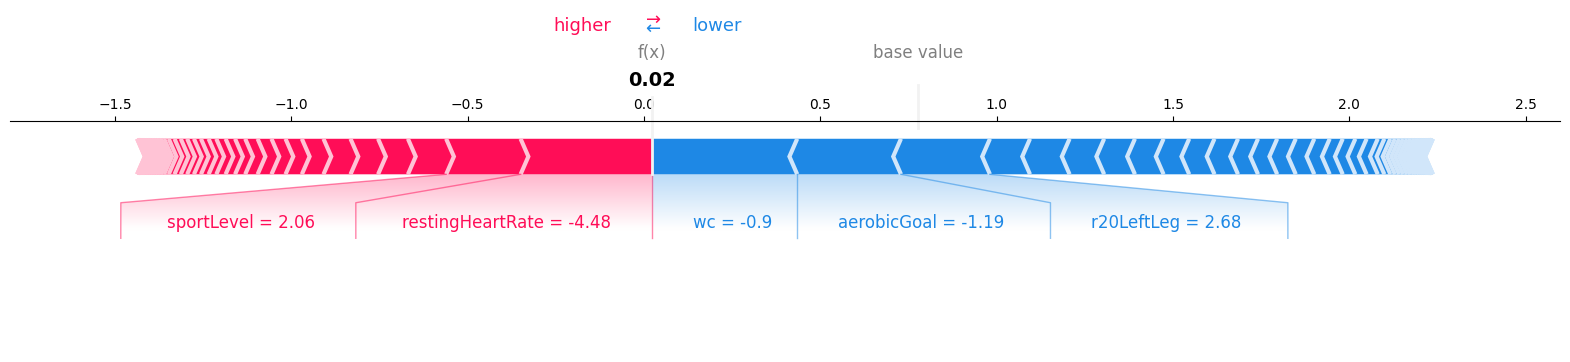


Simulation successful: The health risk pipeline is now ready for clinical deployment.


In [ ]:
# Loading the original master dataset to extract a sample for simulation
df_real_population = pd.read_csv('data/Anovator_Biological_Master.csv')

# Selecting a specific client record to simulate a real-time health consultation
# Researching the model's ability to generate immediate, individualized insights
sample_client_scan = df_real_population.iloc[[10]] 

# Generating the comprehensive Zdravoletie health intelligence report
# Orchestrating the end-to-end flow from raw biometric input to expert advice
generate_consultant_report(
    sample_client_scan, 
    model, 
    scaler, 
    required_features
)